In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
#AT = temperature
# v => Vaccum
# AP => pressure
# RH =>humidity

# PE => produced energy


In [7]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [8]:
X = df.drop("PE",axis = 1)
y = df["PE"]

In [9]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [11]:
# Split our data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y , test_size = 0.2 , random_state =42
)


In [16]:
df.shape

(9568, 5)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)


X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)


In [20]:
type(X_train_scaled)

numpy.ndarray

In [22]:
type(y_train)
y_train.shape

(7654,)

# Dataset & Dataloader

In [23]:
# here we load raw data from the ram to tensordataset , so we can provide to dataloader to make batches
from torch.utils.data import DataLoader,TensorDataset

train_dataset = TensorDataset(X_train_tensor,y_train_tensor) # we pass feature & labels
test_dataset = TensorDataset(X_test_tensor,y_test_tensor) 


In [25]:
train_loader = DataLoader(train_dataset, batch_size =32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size =32)

# Building ANN Model

In [43]:
# Define our model
class ANN(nn.Module):
    def __init__(self):
        super(ANN ,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer 
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6,1),
            
        )
    def forward(self,x):
        return self.model(x)
       

In [44]:
import torch.optim as optim

model = ANN()

# loss,optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [45]:
# Train a ANN
train_losses = []
val_losses =[]

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epochs

    for xb,yb in train_loader:
        #xb => featur of 1 batch
        #yb => labels of 1 batch

        optimizer.zero_grad()
        outputs = model(xb) # forward prop... predicts output for this batch
        loss = crietrion(outputs, yb) # comput loss
        loss.backward() # back prop.. compute gradient
        optimizer.step() # update paramets

        running_loss+=loss.item() #loss is tensor => python float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

        epoch_val_loss = running_val_loss /len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

        if epoch_val_loss <best_val_loss:
            best_val_loss =epoch_val_loss
            torch.save(model.state_dict(), "best_model.pt")
            

    

epoch 1/100 ==> train loss = 205674.23704427082 & val loss = 203149.8125
epoch 2/100 ==> train loss = 192756.737890625 & val loss = 176591.234375
epoch 3/100 ==> train loss = 150278.11998697917 & val loss = 120431.703125
epoch 4/100 ==> train loss = 89743.80865885416 & val loss = 62766.66015625
epoch 5/100 ==> train loss = 45009.39490559896 & val loss = 32940.05859375
epoch 6/100 ==> train loss = 26856.299918619792 & val loss = 22802.814453125
epoch 7/100 ==> train loss = 20286.921716308592 & val loss = 18129.23046875
epoch 8/100 ==> train loss = 16388.060176595052 & val loss = 14598.8779296875
epoch 9/100 ==> train loss = 13016.337052408855 & val loss = 11292.4228515625
epoch 10/100 ==> train loss = 9776.266823323567 & val loss = 8162.30615234375
epoch 11/100 ==> train loss = 6809.864793904622 & val loss = 5444.060546875
epoch 12/100 ==> train loss = 4400.503542073568 & val loss = 3466.60986328125
epoch 13/100 ==> train loss = 2799.253486633301 & val loss = 2236.588134765625
epoch 14/

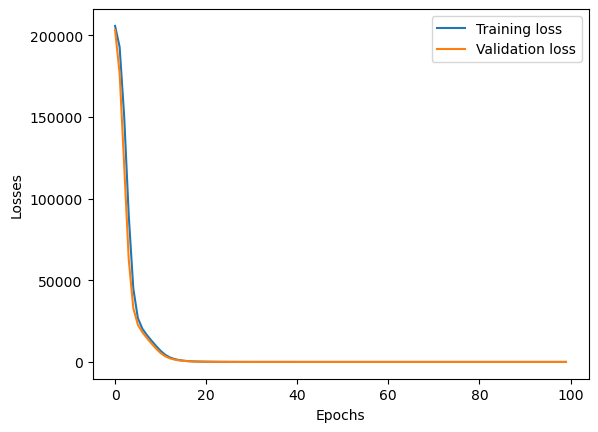

In [46]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training loss" :train_losses,
    "Validation loss" : val_losses
})

plt.plot(loss_df["Training loss"], label = "Training loss")
plt.plot(loss_df["Validation loss"], label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [49]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [51]:
# Evalution
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds,y_train_tensor)
    test_mse_loss = crietrion(test_preds,y_test_tensor)

print("Training MSE :" ,train_mse_loss.item())
print("Testing MSE :" ,test_mse_loss.item())
    
    

Training MSE : 21.17003631591797
Testing MSE : 19.597129821777344


In [53]:
from sklearn.metrics import r2_score

print("r^2_score :",r2_score(y_test,test_preds))  # actual val , predict val

r^2_score : 0.9315130917145086


In [57]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["actual Values"])

pd.concat([predicted_df,actual_df] , axis = 1)

,Predicted Values,actual Values
0,435.853790,433.27
1,436.934998,438.16
2,461.132843,458.42
3,475.806793,480.82
4,435.665466,441.41
...,...,...
1909,451.348846,456.70
1910,431.895752,438.04
1911,467.984741,467.80
1912,431.277008,437.14
